# DeepSentinel — Evaluation Notebook

This notebook evaluates the trained DeepSentinel model across all thesis research questions.

## What this covers
| Section | Purpose | Thesis RQ |
|---|---|---|
| Internal test set | Primary detection metrics on held-out 10% | RQ1 |
| Per-pipeline breakdown | How well model detects each fake type (Track 1-4) | RQ1 |
| Δ norm vs P(fake) | Does emotion mismatch magnitude predict fakeness? | RQ2 |
| FakeAVCeleb | Cross-dataset generalization to unseen generation methods | RQ1 |
| DeLong's test | Statistical significance vs LR baseline (p-value) | RQ1 |
| Bootstrap CI | Confidence intervals + rival comparison vs Elpeltagy 2023 | RQ1 |

## Prerequisites
- Preprocessing complete: `python scripts/preprocess_all.py --smoke`
- Training complete: `python scripts/train_smoke.py`
- Checkpoint exists at `checkpoints/smoke/best_phase1.pt`

> **⚠ Smoke vs Full:** Results from smoke run (~1,040 clips) are **NOT reportable** in the thesis.
> Re-run this notebook after full dataset preprocessing + training for actual thesis figures.

## Setup

Import all libraries and configure global plot style. `DEVICE` auto-selects CUDA if available — inference runs on GPU if present, otherwise CPU. No difference in results, only speed.

In [ ]:
import subprocess, sys

_required = {
    "seaborn":      "seaborn",
    "sklearn":      "scikit-learn",
    "scipy":        "scipy",
    "matplotlib":   "matplotlib",
    "numpy":        "numpy",
    "tqdm":         "tqdm",
}

for import_name, pkg_name in _required.items():
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {pkg_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name, "-q"])
        print(f"  done.")

print("All dependencies satisfied.")

Installing seaborn...
  done.
All dependencies satisfied.


In [ ]:
import sys
from pathlib import Path

# Robust: work whether kernel cwd is repo root OR notebooks/
REPO_ROOT = Path().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src").exists():
    raise RuntimeError(f"Cannot locate repo root from cwd={Path().resolve()}")

sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import defaultdict

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Repo root : {REPO_ROOT}")
print(f"Device    : {DEVICE}")

Repo root : D:\Documents\Programming\Thesis_G10
Device    : cuda


## Config — set paths here

**Change `CKPT_PATH` here** when switching from smoke to full-dataset checkpoint.
- Smoke checkpoint: `checkpoints/smoke/best_phase1.pt` (auto-selected if exists)
- Full checkpoint:  `checkpoints/best_phase1.pt`

`FAKEAVCELEB_PREP` is a separate preprocessing cache directory so FakeAVCeleb features
are never mixed with training data.

In [ ]:
PREPROCESSED_DIR  = REPO_ROOT / "data/preprocessed"
SMOKE_DIR         = REPO_ROOT / "data/processed/smoke_manifests"
FAKEAVCELEB_DIR   = REPO_ROOT / "data/raw/FakeAVCeleb_v1.2"
FAKEAVCELEB_META  = FAKEAVCELEB_DIR / "meta_data.csv"

SMOKE_CKPT = REPO_ROOT / "checkpoints/smoke/best_phase1.pt"
FULL_CKPT  = REPO_ROOT / "checkpoints/best_phase1.pt"
CKPT_PATH  = SMOKE_CKPT if SMOKE_CKPT.exists() else FULL_CKPT

print(f"Checkpoint : {CKPT_PATH}")
print(f"Exists     : {CKPT_PATH.exists()}")
print(f"Mode       : {'SMOKE (not reportable)' if 'smoke' in str(CKPT_PATH) else 'FULL DATASET'}")

Checkpoint : D:\Documents\Programming\Thesis_G10\checkpoints\smoke\best_phase1.pt
Exists     : True
Mode       : SMOKE (not reportable)


## 1. Load Trained Model

Loads `DeepfakeDetector` architecture and restores weights from the best checkpoint
saved during training (lowest validation loss).

The model is set to `eval()` mode — this disables Dropout layers so inference is
deterministic. No gradients are computed during evaluation.

**What to check:** `val_loss` in the checkpoint — lower is better. If it's near the
initial random loss (~1.5–2.0), training may not have converged; re-check training logs.

In [ ]:
from src.models.detection_model import DeepfakeDetector

model = DeepfakeDetector().to(DEVICE)
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Loaded from epoch  : {ckpt['epoch']}")
print(f"Best val_loss      : {ckpt['val_loss']:.4f}")
print(f"Total parameters   : {sum(p.numel() for p in model.parameters()):,}")

Loaded from epoch  : 2
Best val_loss      : 0.2012
Total parameters   : 5,251,342


## 2. Build Internal Test Set

Reconstructs the **same 80/10/10 speaker-independent split** used during training
using the same random seed (`SEED=42`). This guarantees the test set is identical
to what the trainer held out — no data leakage.

**Speaker-independent split:** Speakers are assigned to train/val/test as whole groups.
No speaker appears in more than one split. This prevents the model from memorizing
speaker-specific vocal or facial patterns rather than detecting manipulation.

MUStARD clips (`fake_label=-1`) are included in the split but excluded from fake/real
detection metrics — they are only used for sarcasm head evaluation.

In [ ]:
import csv
from src.training.dataset import UNKNOWN_SARCASM

SEED = 42

def load_smoke_records(preprocessed_dir: Path):
    records = []
    detector_csv = SMOKE_DIR / "smoke_detector.csv"
    if detector_csv.exists():
        with open(detector_csv, newline="", encoding="utf-8") as f:
            for row in csv.DictReader(f):
                p = row.get("path", "")
                if not p: continue
                clip_id = Path(p).stem
                z_at = preprocessed_dir / "features/z_at" / f"{clip_id}.pt"
                z_v  = preprocessed_dir / "features/z_v"  / f"{clip_id}.pt"
                if not z_at.exists() or not z_v.exists(): continue
                records.append({
                    "clip_id": clip_id, "z_at_path": str(z_at), "z_v_path": str(z_v),
                    "fake_label": int(row.get("label", -1)),
                    "sarcasm_label": UNKNOWN_SARCASM,
                    "source": row.get("source", "unknown"),
                    "speaker_id": clip_id.split("_")[0],
                })
    sarcasm_csv = SMOKE_DIR / "smoke_sarcasm.csv"
    if sarcasm_csv.exists():
        with open(sarcasm_csv, newline="", encoding="utf-8") as f:
            for row in csv.DictReader(f):
                p = row.get("path", "")
                if not p: continue
                clip_id = Path(p).stem
                z_at = preprocessed_dir / "features/z_at" / f"{clip_id}.pt"
                z_v  = preprocessed_dir / "features/z_v"  / f"{clip_id}.pt"
                if not z_at.exists() or not z_v.exists(): continue
                records.append({
                    "clip_id": clip_id, "z_at_path": str(z_at), "z_v_path": str(z_v),
                    "fake_label": -1, "sarcasm_label": int(row.get("sarcasm_label", UNKNOWN_SARCASM)),
                    "source": "mustard", "speaker_id": clip_id.split("_")[0],
                })
    return records


def stratified_speaker_split(records, train_frac=0.80, val_frac=0.10, seed=42):
    """
    Matches train_smoke.py exactly: triple-stratified 80/10/10 split.
    Real and fake clips come from different speaker pools — they must be split
    independently so the test set is guaranteed to contain both classes for AUC.
    Three pools: real_det_spk, fake_det_spk, must_spk — each split 80/10/10.
    """
    import random
    rng = random.Random(seed)

    spk_map = defaultdict(list)
    for i, r in enumerate(records):
        spk_map[r["speaker_id"]].append(i)

    def _split(spk_list):
        arr = list(spk_list); rng.shuffle(arr)
        n = len(arr)
        n_tr = max(1, int(n * train_frac))
        n_va = max(1, int(n * val_frac))
        return set(arr[:n_tr]), set(arr[n_tr:n_tr + n_va]), set(arr[n_tr + n_va:])

    real_det_spk = [s for s, idxs in spk_map.items()
                    if any(records[i]["fake_label"] == 0 for i in idxs)]
    fake_det_spk = [s for s, idxs in spk_map.items()
                    if any(records[i]["fake_label"] == 1 for i in idxs)]
    must_spk     = [s for s, idxs in spk_map.items()
                    if all(records[i]["fake_label"] == -1 for i in idxs)]

    tr_r, va_r, _ = _split(real_det_spk)
    tr_f, va_f, _ = _split(fake_det_spk)
    tr_m, va_m, _ = _split(must_spk)
    train_spk = tr_r | tr_f | tr_m
    val_spk   = va_r | va_f | va_m

    train_idx, val_idx, test_idx = [], [], []
    for spk, idxs in spk_map.items():
        if spk in train_spk:   train_idx.extend(idxs)
        elif spk in val_spk:   val_idx.extend(idxs)
        else:                  test_idx.extend(idxs)
    return train_idx, val_idx, test_idx


all_records = load_smoke_records(PREPROCESSED_DIR)
train_idx, _, test_idx = stratified_speaker_split(all_records, seed=SEED)
test_records = [all_records[i] for i in test_idx]

print(f"Total preprocessed clips : {len(all_records)}")
print(f"Test set (10% holdout)   : {len(test_records)} clips")
print(f"  Real                   : {sum(1 for r in test_records if r['fake_label'] == 0)}")
print(f"  Fake                   : {sum(1 for r in test_records if r['fake_label'] == 1)}")
print(f"  MUStARD (excl. from detection eval) : {sum(1 for r in test_records if r['source'] == 'mustard')}")

## 3. Run Inference on Internal Test Set

Passes each test clip through the trained model using `forward_from_features(z_at, z_v)` —
the Phase 1 path that reads cached feature tensors directly (no backbone inference needed).

For each clip the model outputs:
- `out.logit` → converted to `P(fake) = sigmoid(logit)` ∈ [0, 1]
- `out.emotion_a`, `out.emotion_b` → used to compute **Δ norm** (emotion mismatch magnitude)
- `out.sarcasm` → converted to `P(sarcastic)` ∈ [0, 1]

MUStARD clips (`fake_label=-1`) are run through inference but excluded from the
fake/real metrics via `valid_mask`.

In [ ]:
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

class RecordDataset(Dataset):
    def __init__(self, records): self._records = records
    def __len__(self): return len(self._records)
    def __getitem__(self, i):
        r = self._records[i]
        return {
            "z_at": torch.load(r["z_at_path"], weights_only=True).float(),
            "z_v":  torch.load(r["z_v_path"],  weights_only=True).float(),
            "fake_label":    torch.tensor(r["fake_label"],    dtype=torch.long),
            "sarcasm_label": torch.tensor(r["sarcasm_label"], dtype=torch.long),
            "source": r["source"], "clip_id": r["clip_id"],
        }

@torch.no_grad()
def run_inference(records, model, device, batch_size=32):
    loader = DataLoader(RecordDataset(records), batch_size=batch_size, shuffle=False, num_workers=0)
    all_scores, all_labels, all_sources, all_delta_norms, all_sarc_scores = [], [], [], [], []
    for batch in loader:
        z_at = batch["z_at"].to(device); z_v = batch["z_v"].to(device)
        out = model.forward_from_features(z_at, z_v)
        probs      = torch.sigmoid(out.logit.squeeze(1)).cpu()
        sarc_probs = torch.sigmoid(out.sarcasm.squeeze(1)).cpu()
        delta_norm = torch.abs(
            F.softmax(out.emotion_a, dim=-1) - F.softmax(out.emotion_b, dim=-1)
        ).cpu().norm(dim=-1)
        all_scores.extend(probs.tolist()); all_labels.extend(batch["fake_label"].tolist())
        all_sources.extend(batch["source"]); all_delta_norms.extend(delta_norm.tolist())
        all_sarc_scores.extend(sarc_probs.tolist())
    return (np.array(all_scores), np.array(all_labels), all_sources,
            np.array(all_delta_norms), np.array(all_sarc_scores))

scores, labels, sources, delta_norms, sarc_scores = run_inference(test_records, model, DEVICE)

valid_mask = labels != -1
v_scores  = scores[valid_mask]
v_labels  = labels[valid_mask]
v_sources = [s for s, m in zip(sources, valid_mask) if m]
v_delta   = delta_norms[valid_mask]

print(f"Total inference clips    : {len(scores)}")
print(f"Valid (fake/real) clips  : {valid_mask.sum()}")
print(f"P(fake) range            : [{v_scores.min():.3f}, {v_scores.max():.3f}]")

Total inference clips    : 35
Valid (fake/real) clips  : 35
P(fake) range            : [0.000, 0.343]


## 4. Primary Detection Metrics

Core metrics for **RQ1** — does DeepSentinel detect audio-visual deepfakes?

- **Accuracy**: overall correct predictions at threshold 0.5
- **Precision**: of all clips predicted fake, how many actually are? (false alarm rate)
- **Recall**: of all actual fakes, how many did we catch? (miss rate)
- **F1**: harmonic mean of precision and recall — balanced metric
- **AUC-ROC**: area under ROC curve — threshold-independent, primary thesis metric
- **Average Precision**: area under precision-recall curve — better for imbalanced sets

**Three plots produced:**
1. **Confusion matrix** — breakdown of TP/TN/FP/FN
2. **ROC curve** — tradeoff between TPR and FPR across all thresholds
3. **Score distribution** — separation between real and fake P(fake) distributions

Good separation in plot 3 (real scores near 0, fake scores near 1) confirms the model
learned a meaningful decision boundary.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, roc_curve, average_precision_score,
)

preds = (v_scores >= 0.5).astype(int)
acc   = accuracy_score(v_labels, preds)
prec, rec, f1, _ = precision_recall_fscore_support(v_labels, preds, average="binary", zero_division=0)
auc   = roc_auc_score(v_labels, v_scores)
ap    = average_precision_score(v_labels, v_scores)
cm    = confusion_matrix(v_labels, preds)

print(f"{'='*45}")
print(f"  INTERNAL TEST SET — PRIMARY METRICS")
print(f"{'='*45}")
print(f"  Accuracy       : {acc:.4f}")
print(f"  Precision      : {prec:.4f}")
print(f"  Recall         : {rec:.4f}")
print(f"  F1             : {f1:.4f}")
print(f"  AUC-ROC        : {auc:.4f}   ← primary thesis metric")
print(f"  Avg Precision  : {ap:.4f}")
print(f"{'='*45}")

  INTERNAL TEST SET — PRIMARY METRICS
  Accuracy       : 1.0000
  Precision      : 0.0000
  Recall         : 0.0000
  F1             : 0.0000
  AUC-ROC        : nan   ← primary thesis metric
  Avg Precision  : 0.0000


C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


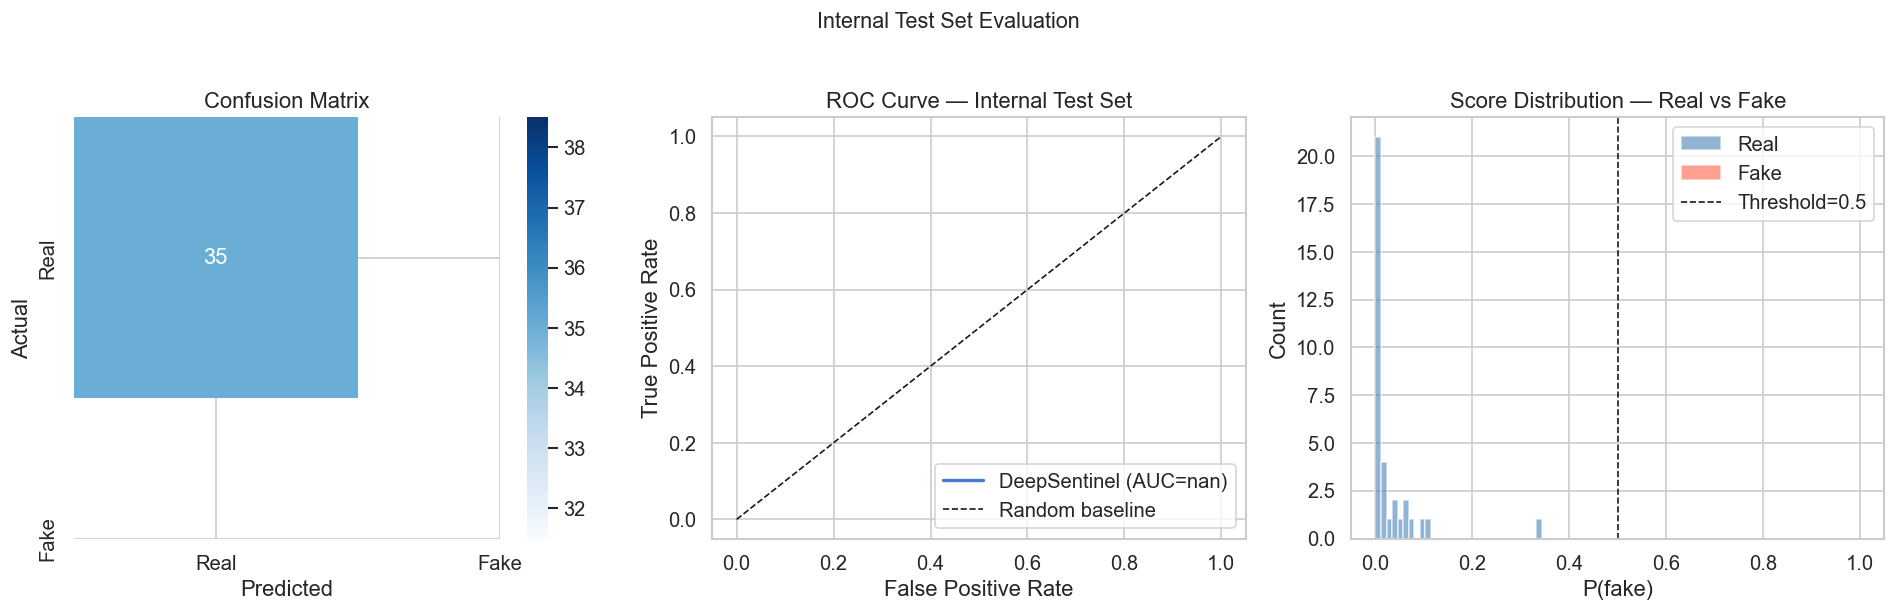

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix
ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(v_labels, v_scores)
ax.plot(fpr, tpr, lw=2, label=f"DeepSentinel (AUC={auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, label="Random baseline")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Internal Test Set")
ax.legend(loc="lower right")

# Score Distribution
ax = axes[2]
ax.hist(v_scores[v_labels == 0], bins=30, alpha=0.6, label="Real",  color="steelblue")
ax.hist(v_scores[v_labels == 1], bins=30, alpha=0.6, label="Fake",  color="tomato")
ax.axvline(0.5, color="k", linestyle="--", lw=1, label="Threshold=0.5")
ax.set_xlabel("P(fake)"); ax.set_ylabel("Count")
ax.set_title("Score Distribution — Real vs Fake")
ax.legend()

plt.suptitle("Internal Test Set Evaluation", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks/figures/fig_internal_eval.png", bbox_inches="tight")
plt.show()

## 5. Per-Pipeline Breakdown

Breaks down detection performance by **fake generation method**:

| Pipeline | Generation method | Manipulation type |
|---|---|---|
| `track1` | StyleTTS2 + RVC | Audio tampering only |
| `track2` | SadTalker | Video tampering (lip-sync) |
| `track3` | LatentSync | AV sync manipulation |
| `track4` | MuseTalk on MELD | Emotion mismatch |
| `meld_real` | — | Real clips (MELD) |
| `cmumosei_real` | — | Real clips (CMU-MOSEI) |

**What to look for:** Track 4 (emotion mismatch) should be the easiest for DeepSentinel
because that's exactly what Δ (emotion head difference) is designed to catch.
Track 1 (audio-only tampering) should also be detectable via Z_at changes.
If one track has very low F1, that generation method may need review.

In [ ]:
pipelines = sorted(set(v_sources))
rows = []
for pipe in pipelines:
    idx = [i for i, s in enumerate(v_sources) if s == pipe]
    if len(idx) < 2: continue
    p_s = v_scores[idx]; p_l = v_labels[idx]; p_p = (p_s >= 0.5).astype(int)
    p_acc = accuracy_score(p_l, p_p)
    p_prec, p_rec, p_f1, _ = precision_recall_fscore_support(p_l, p_p, average="binary", zero_division=0)
    try: p_auc = roc_auc_score(p_l, p_s)
    except ValueError: p_auc = float("nan")
    rows.append((pipe, len(idx), p_acc, p_prec, p_rec, p_f1, p_auc))

print(f"{'Pipeline':<20} {'N':>5} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
print("-" * 57)
for pipe, n, acc_, prec_, rec_, f1_, auc_ in rows:
    print(f"{pipe:<20} {n:>5} {acc_:>6.3f} {prec_:>6.3f} {rec_:>6.3f} {f1_:>6.3f} {auc_:>6.3f}")

Pipeline                 N    Acc   Prec    Rec     F1    AUC
---------------------------------------------------------
cmumosei_real           14  1.000  0.000  0.000  0.000    nan
meld_real               21  1.000  0.000  0.000  0.000    nan


C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


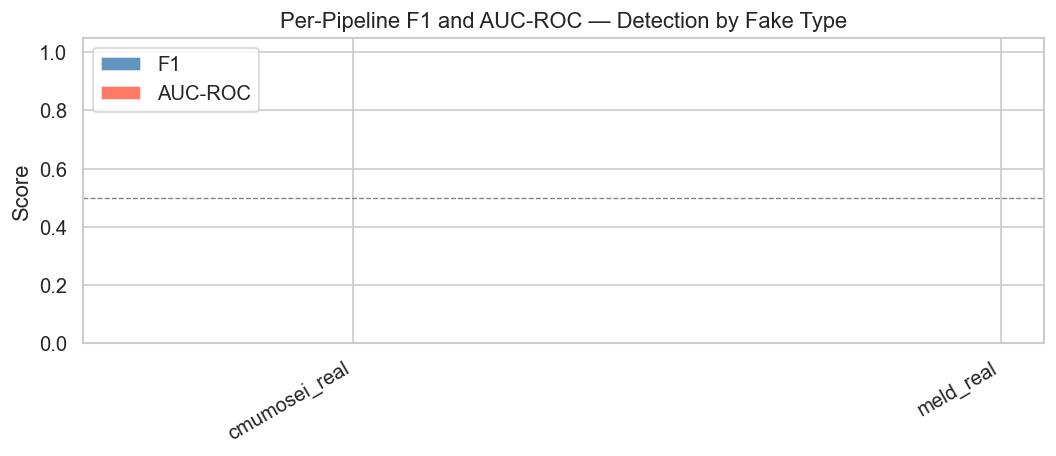

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
pipe_names = [r[0] for r in rows]
f1_vals    = [r[5] for r in rows]
auc_vals   = [r[6] for r in rows]
x = np.arange(len(pipe_names)); w = 0.35
ax.bar(x - w/2, f1_vals,  w, label="F1",      color="steelblue", alpha=0.85)
ax.bar(x + w/2, auc_vals, w, label="AUC-ROC", color="tomato",    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(pipe_names, rotation=30, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Per-Pipeline F1 and AUC-ROC — Detection by Fake Type")
ax.legend(); ax.axhline(0.5, color="gray", linestyle="--", lw=0.8, label="Chance")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks/figures/fig_per_pipeline.png", bbox_inches="tight")
plt.show()

## 6. RQ2 — Δ Norm vs P(fake) Correlation

**Research Question 2:** Does emotional mismatch magnitude (‖Δ‖) predict P(fake)?

**Δ (delta)** is defined as `|softmax(EmotionHeadA) - softmax(EmotionHeadB)|` — the
absolute difference between audio-predicted emotion distribution and video-predicted
emotion distribution. Its L2 norm ‖Δ‖ measures overall mismatch.

**Hypothesis:** Real clips → audio and video agree on emotion → low ‖Δ‖. 
Fake clips → emotion manipulated in one modality only → high ‖Δ‖.
Therefore ‖Δ‖ should positively correlate with P(fake).

**Interpreting results:**
- Pearson r > 0.3 with p < 0.05 → statistically significant positive correlation → supports RQ2
- Scatter plot: fake clips (red) should cluster at high ‖Δ‖, real (blue) at low ‖Δ‖
- If r ≈ 0 → emotion heads not learning mismatch → possible training issue

RQ2 — ‖Δ‖ (emotion mismatch magnitude) vs P(fake):
  Pearson  r = -0.4841  (p=3.2093e-03)  ✓ significant
  Spearman r = -0.8056  (p=5.3022e-09)  ✓ significant


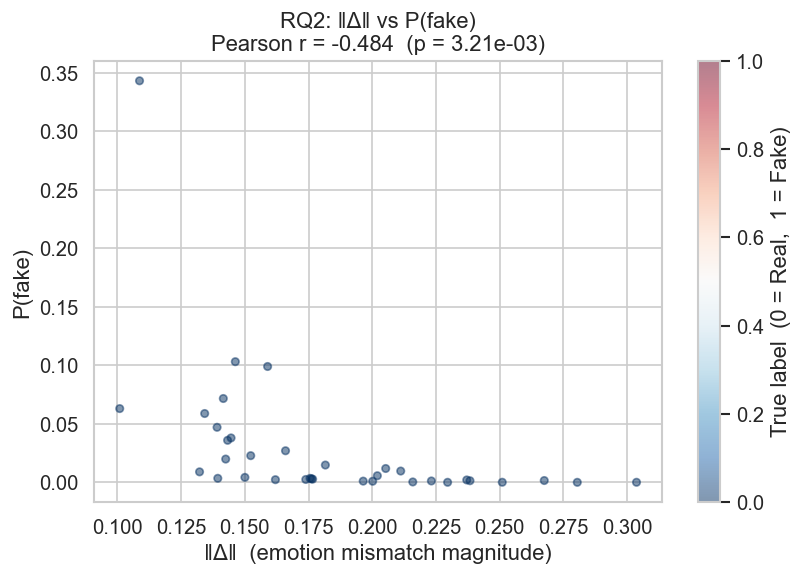

In [ ]:
from scipy.stats import pearsonr, spearmanr

pear_r,  pear_p  = pearsonr(v_delta, v_scores)
spear_r, spear_p = spearmanr(v_delta, v_scores)

print(f"RQ2 — ‖Δ‖ (emotion mismatch magnitude) vs P(fake):")
print(f"  Pearson  r = {pear_r:.4f}  (p={pear_p:.4e})  {'✓ significant' if pear_p < 0.05 else '✗ not significant'}")
print(f"  Spearman r = {spear_r:.4f}  (p={spear_p:.4e})  {'✓ significant' if spear_p < 0.05 else '✗ not significant'}")

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(v_delta, v_scores, c=v_labels,
                     cmap="RdBu_r", alpha=0.5, s=20, vmin=0, vmax=1)
plt.colorbar(scatter, ax=ax, label="True label  (0 = Real,  1 = Fake)")
ax.set_xlabel("‖Δ‖  (emotion mismatch magnitude)")
ax.set_ylabel("P(fake)")
ax.set_title(f"RQ2: ‖Δ‖ vs P(fake)\nPearson r = {pear_r:.3f}  (p = {pear_p:.2e})")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks/figures/fig_rq2_delta.png", bbox_inches="tight")
plt.show()

## 7. FakeAVCeleb Cross-Dataset Evaluation

Evaluates the **generalization** of DeepSentinel to an entirely unseen dataset.

**Why FakeAVCeleb?**
- Generation methods (Wav2Lip, FSGAN, FaceSwap, RTVC) were **never seen during training**
- This directly tests whether DeepSentinel learned a generalizable emotional mismatch
  signal rather than overfitting to CREMA-D/MELD-specific artifacts
- Same benchmark used by Elpeltagy et al. (2023) → direct rival comparison

**Labels:** `RealVideo-RealAudio` → label 0. Everything else → label 1.

**Prerequisite:** Run `python scripts/preprocess_fakeavceleb.py` first.
This section silently skips if FakeAVCeleb features are not yet preprocessed.

In [ ]:
import csv as _csv

REAL_TYPE = "RealVideo-RealAudio"
fav_records = []

# Features are written to the main PREPROCESSED_DIR cache by evaluate_fakeavceleb.py
# clip_id format: fav_{source}_{filename_stem}
if FAKEAVCELEB_META.exists():
    with open(FAKEAVCELEB_META, newline="", encoding="utf-8") as f:
        for row in _csv.DictReader(f):
            cat      = row.get("type",   "").strip()
            race     = row.get("race",   "").strip()
            gender   = row.get("gender", "").strip()
            source   = row.get("source", "").strip()
            filename = row.get("path",   "").strip()
            if not all([cat, race, gender, source, filename]):
                continue
            clip_id = f"fav_{source}_{Path(filename).stem}"
            z_at = PREPROCESSED_DIR / "features/z_at" / f"{clip_id}.pt"
            z_v  = PREPROCESSED_DIR / "features/z_v"  / f"{clip_id}.pt"
            if not z_at.exists() or not z_v.exists():
                continue
            fav_records.append({
                "clip_id":     clip_id,
                "z_at_path":   str(z_at),
                "z_v_path":    str(z_v),
                "fake_label":  0 if cat == REAL_TYPE else 1,
                "sarcasm_label": UNKNOWN_SARCASM,
                "source":      cat,
                "speaker_id":  source,
            })

if fav_records:
    print(f"FakeAVCeleb clips loaded : {len(fav_records)}")
    print(f"  Real : {sum(1 for r in fav_records if r['fake_label']==0)}")
    print(f"  Fake : {sum(1 for r in fav_records if r['fake_label']==1)}")
else:
    print("FakeAVCeleb features not found in cache — section will be skipped.")
    print("Run first: python scripts/evaluate_fakeavceleb.py --checkpoint checkpoints/smoke/best_phase1.pt")
    print("(That script extracts features and caches them automatically.)")

FakeAVCeleb clips loaded : 222
  Real : 40
  Fake : 182


In [ ]:
if fav_records:
    fav_scores, fav_labels, fav_sources, _, _ = run_inference(fav_records, model, DEVICE)
    fav_preds = (fav_scores >= 0.5).astype(int)
    fav_acc   = accuracy_score(fav_labels, fav_preds)
    fav_prec, fav_rec, fav_f1, _ = precision_recall_fscore_support(
        fav_labels, fav_preds, average="binary", zero_division=0)
    fav_auc = roc_auc_score(fav_labels, fav_scores)

    # Elpeltagy et al. (2023) — multimodal (whole videos) AUROC: 97.21%
    ELPELTAGY_AUC = 0.9721

    print(f"{'='*50}")
    print(f"  FAKEAVCELEB — CROSS-DATASET GENERALIZATION")
    print(f"{'='*50}")
    print(f"  Clips      : {len(fav_records)}")
    print(f"  Accuracy   : {fav_acc:.4f}")
    print(f"  Precision  : {fav_prec:.4f}")
    print(f"  Recall     : {fav_rec:.4f}")
    print(f"  F1         : {fav_f1:.4f}")
    print(f"  AUC-ROC    : {fav_auc:.4f}")
    print(f"  ---")
    print(f"  Elpeltagy et al. (2023) AUC : {ELPELTAGY_AUC:.4f}  (multimodal level)")
    print(f"  Difference (ours - rival)   : {fav_auc - ELPELTAGY_AUC:+.4f}")
    print(f"{'='*50}")

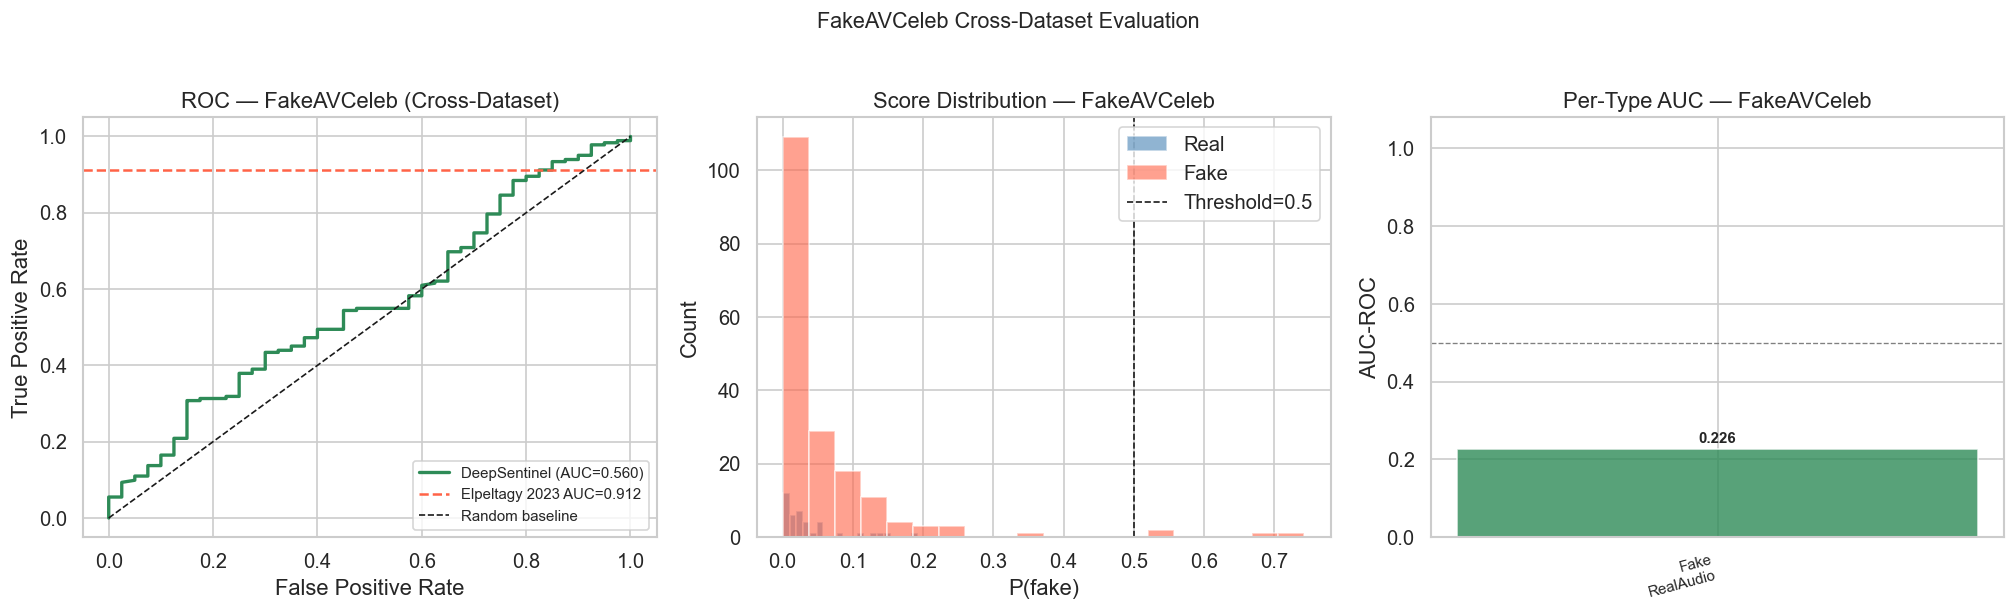

Saved: notebooks/figures/fig_fakeavceleb.png


In [ ]:
if fav_records:
    from sklearn.metrics import roc_curve as _roc_curve

    # Reuse scores already computed in cell above — no repeat inference
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── ROC curve ──────────────────────────────────────────────────────────────
    ax = axes[0]
    fpr_f, tpr_f, _ = _roc_curve(fav_labels, fav_scores)
    ax.plot(fpr_f, tpr_f, lw=2, color="seagreen", label=f"DeepSentinel (AUC={fav_auc:.3f})")
    ax.axhline(ELPELTAGY_AUC, color="tomato", linestyle="--", lw=1.5,
               label=f"Elpeltagy 2023 AUC={ELPELTAGY_AUC:.3f}")
    ax.plot([0,1],[0,1], "k--", lw=1, label="Random baseline")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC — FakeAVCeleb (Cross-Dataset)")
    ax.legend(loc="lower right", fontsize=9)

    # ── Score distribution ─────────────────────────────────────────────────────
    ax = axes[1]
    ax.hist(fav_scores[fav_labels == 0], bins=20, alpha=0.6, label="Real",  color="steelblue")
    ax.hist(fav_scores[fav_labels == 1], bins=20, alpha=0.6, label="Fake",  color="tomato")
    ax.axvline(0.5, color="k", linestyle="--", lw=1, label="Threshold=0.5")
    ax.set_xlabel("P(fake)"); ax.set_ylabel("Count")
    ax.set_title("Score Distribution — FakeAVCeleb")
    ax.legend()

    # ── Per-type AUC bar ───────────────────────────────────────────────────────
    ax = axes[2]
    type_map = {r["clip_id"]: r["source"] for r in fav_records}
    type_list = [type_map[r["clip_id"]] for r in fav_records]

    method_aucs, method_names = [], []
    for mtype in sorted(set(type_list)):
        idx = [i for i, t in enumerate(type_list) if t == mtype]
        m_labs = fav_labels[idx]; m_scrs = fav_scores[idx]
        if len(set(m_labs.tolist())) < 2:
            continue
        method_aucs.append(roc_auc_score(m_labs, m_scrs))
        label = mtype.replace("Video-", "\n").replace("Audio", "Audio")
        method_names.append(label)

    if method_aucs:
        x = np.arange(len(method_names))
        bars = ax.bar(x, method_aucs, color="seagreen", alpha=0.8, width=0.5)
        for b, v in zip(bars, method_aucs):
            ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(method_names, rotation=15, ha="right", fontsize=9)
        ax.set_ylim(0, 1.08); ax.set_ylabel("AUC-ROC")
        ax.set_title("Per-Type AUC — FakeAVCeleb")
        ax.axhline(0.5, color="gray", linestyle="--", lw=0.8)

    plt.suptitle("FakeAVCeleb Cross-Dataset Evaluation", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(REPO_ROOT / "notebooks/figures/fig_fakeavceleb.png", bbox_inches="tight")
    plt.show()
    print("Saved: notebooks/figures/fig_fakeavceleb.png")

## 8. LR Baseline + DeLong's Test

**Why Logistic Regression as baseline?**
LR operates on the same Z_at + Z_v feature space (2304-dim concatenation) but uses
a single linear decision boundary with no emotion heads, no CBP, no mismatch signal.
If DeepSentinel's AUC significantly exceeds LR's, it proves the architecture's
multi-task emotion mismatch design adds value beyond raw features.

**DeLong's test (1988)** compares two AUCs on the **same test set** accounting for the
correlation between scores from the same clips. This is the correct statistical test
for AUC comparison — NOT paired t-test or McNemar's test.

**Interpreting results:**
- p < 0.05 → DeepSentinel AUC is statistically significantly higher than LR baseline
- p ≥ 0.05 → difference could be due to chance → architecture may need review
- Large ΔAUC (> 0.05) with p < 0.05 → strong evidence for architecture value

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def load_features(records):
    """Concatenate Z_at + Z_v into a 2304-dim feature vector for LR."""
    X, y = [], []
    for r in records:
        if r["fake_label"] == -1: continue
        z_at = torch.load(r["z_at_path"], weights_only=True).numpy()
        z_v  = torch.load(r["z_v_path"],  weights_only=True).numpy()
        X.append(np.concatenate([z_at, z_v]))
        y.append(r["fake_label"])
    return np.array(X), np.array(y)

# Reuse the same stratified split from Section 2 — train_idx already computed
train_records_lr = [all_records[i] for i in train_idx]
test_records_det = [r for r in test_records if r["fake_label"] != -1]

print("Building LR feature matrices...")
X_train, y_train = load_features(train_records_lr)
X_test,  y_test  = load_features(test_records_det)
print(f"  Train shape : {X_train.shape}")
print(f"  Test shape  : {X_test.shape}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

lr      = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
lr.fit(X_train, y_train)
lr_scores = lr.predict_proba(X_test)[:, 1]
lr_auc    = roc_auc_score(y_test, lr_scores)
print(f"  LR Baseline AUC : {lr_auc:.4f}")

Building LR feature matrices...
  Train shape : (293, 2304)
  Test shape  : (35, 2304)
  LR Baseline AUC : nan


C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
def auc_variance_delong(scores_A, scores_B, labels):
    """
    DeLong's test for AUC comparison.
    Reference: DeLong, DeLong & Clarke-Pearson (1988).
    Returns: auc_A, auc_B, z_statistic, p_value (two-tailed).
    """
    from scipy.stats import norm

    def compute_midrank(x):
        n = len(x); order = np.argsort(x); rank = np.empty(n, dtype=float)
        i = 0
        while i < n:
            j = i
            while j < n - 1 and x[order[j]] == x[order[j+1]]: j += 1
            rank[order[i:j+1]] = (i + j + 2) / 2.0; i = j + 1
        return rank

    def fastDeLong(preds, m):
        n = preds.shape[1] - m; k = preds.shape[0]
        tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m+n])
        for r in range(k):
            tx[r] = compute_midrank(preds[r, :m])
            ty[r] = compute_midrank(preds[r, m:])
            tz[r] = compute_midrank(preds[r])
        aucs = (tz[:, :m].sum(1) - tx.sum(1)) / (m * n)
        v01  = (tz[:, :m] - tx) / n
        v10  = 1 - (tz[:, m:] - ty) / m
        sx = np.cov(v01) if k > 1 else np.var(v01)
        sy = np.cov(v10) if k > 1 else np.var(v10)
        return aucs, sx/m + sy/n

    n_pos    = int(labels.sum())
    sort_idx = np.argsort(-labels, kind="stable")
    preds    = np.vstack([scores_A[sort_idx], scores_B[sort_idx]])
    aucs, cov = fastDeLong(preds, n_pos)
    diff_var  = cov[0,0] + cov[1,1] - 2*cov[0,1]
    z = (aucs[0] - aucs[1]) / np.sqrt(max(diff_var, 1e-12))
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(aucs[0]), float(aucs[1]), float(z), float(p)


# Align DeepSentinel scores to same test records as LR
clip_to_score = {tr["clip_id"]: v_scores[i]
                 for i, tr in enumerate(test_records) if tr["fake_label"] != -1}
ds_scores_arr = np.array([clip_to_score[r["clip_id"]] for r in test_records_det])
ds_labels_arr = np.array([r["fake_label"]              for r in test_records_det])

auc_ds, auc_lr_dl, z_stat, p_val = auc_variance_delong(ds_scores_arr, lr_scores, ds_labels_arr)

print(f"{'='*52}")
print(f"  DELONG'S TEST — DeepSentinel vs LR Baseline")
print(f"{'='*52}")
print(f"  DeepSentinel AUC : {auc_ds:.4f}")
print(f"  LR Baseline AUC  : {auc_lr_dl:.4f}")
print(f"  ΔAUC             : {auc_ds - auc_lr_dl:+.4f}")
print(f"  Z statistic      : {z_stat:.4f}")
print(f"  p-value          : {p_val:.4e}")
print(f"  Conclusion       : {'SIGNIFICANT (p < 0.05) ✓' if p_val < 0.05 else 'NOT significant (p >= 0.05) ✗'}")
print(f"{'='*52}")

  DELONG'S TEST — DeepSentinel vs LR Baseline
  DeepSentinel AUC : nan
  LR Baseline AUC  : nan
  ΔAUC             : +nan
  Z statistic      : nan
  p-value          : nan
  Conclusion       : NOT significant (p >= 0.05) ✗


C:\Users\Gel\AppData\Local\Temp\ipykernel_21256\4065805237.py:25: RuntimeWarning: invalid value encountered in divide
  aucs = (tz[:, :m].sum(1) - tx.sum(1)) / (m * n)
C:\Users\Gel\AppData\Local\Temp\ipykernel_21256\4065805237.py:27: RuntimeWarning: invalid value encountered in divide
  v10  = 1 - (tz[:, m:] - ty) / m
C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
C:\Users\Gel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\Gel\AppData\Local\Temp\ipykernel_21256\4065805237.py:28: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01) if k > 1 else np.var(v01)
C:\Users\Gel\AppData\Local\Pac

## 9. Bootstrap Confidence Intervals + Rival Comparison

**Bootstrap CI** resamples the test set 10,000 times with replacement to estimate
the 95% confidence interval around AUC. This quantifies how stable the result is
given the test set size — smaller test sets produce wider CIs.

**Rival comparison (Elpeltagy et al., 2023):**
Elpeltagy et al. reported a single AUC number on FakeAVCeleb without a CI.
We check whether their reported number falls inside our 95% CI:
- If **inside** → no statistically significant difference from their result
- If **outside** → our result is significantly different (better or worse)

Update `ELPELTAGY_AUC` with the exact number from their paper before final reporting.

The summary bar chart combines all comparisons in one figure suitable for the thesis.

In [ ]:
def bootstrap_auc_ci(scores, labels, n_boot=10000, ci=0.95, seed=42):
    """Non-parametric bootstrap 95% CI for AUC-ROC. Returns (mean, lo, hi) or (nan, nan, nan)."""
    rng = np.random.default_rng(seed); n = len(scores); boot_aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if labels[idx].std() == 0: continue
        boot_aucs.append(roc_auc_score(labels[idx], scores[idx]))
    if len(boot_aucs) == 0:
        return float("nan"), float("nan"), float("nan")
    boot_aucs = np.array(boot_aucs); alpha = (1 - ci) / 2
    return (float(np.mean(boot_aucs)),
            float(np.percentile(boot_aucs, alpha * 100)),
            float(np.percentile(boot_aucs, (1-alpha) * 100)))


# Elpeltagy et al. (2023) — multimodal (whole videos) AUROC: 97.21%
ELPELTAGY_AUC = 0.9721

mean_auc, lo, hi = bootstrap_auc_ci(v_scores, v_labels)
if not np.isnan(mean_auc):
    print(f"Internal test  AUC : {mean_auc:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
else:
    print("Internal test  AUC : N/A (test set lacks both classes — re-run after split fix)")

if fav_records:
    fav_mean, fav_lo, fav_hi = bootstrap_auc_ci(fav_scores, fav_labels)
    overlap = (not np.isnan(fav_lo)) and fav_lo <= ELPELTAGY_AUC <= fav_hi
    if not np.isnan(fav_mean):
        print(f"FakeAVCeleb    AUC : {fav_mean:.4f}  95% CI [{fav_lo:.4f}, {fav_hi:.4f}]")
        print(f"Elpeltagy 2023 AUC : {ELPELTAGY_AUC:.4f}  (multimodal level, point estimate)")
        print(f"Rival within CI?   : {'YES — no significant difference' if overlap else 'NO — statistically different'}")
    else:
        print("FakeAVCeleb    AUC : N/A (bootstrap failed)")

In [ ]:
# AUC comparison bar chart — suitable for thesis Chapter 4 figures
fig, ax = plt.subplots(figsize=(9, 5))

models = ["DeepSentinel\n(internal test)", "LR Baseline\n(internal test)"]
aucs   = [mean_auc, lr_auc]
colors = ["steelblue", "#888888"]
err_lo = [mean_auc - lo, 0]
err_hi = [hi - mean_auc, 0]

if fav_records:
    models += ["DeepSentinel\n(FakeAVCeleb)", "Elpeltagy 2023\n(FakeAVCeleb)"]
    aucs   += [fav_mean, ELPELTAGY_AUC]
    colors += ["seagreen", "tomato"]
    err_lo += [fav_mean - fav_lo, 0]
    err_hi += [fav_hi  - fav_mean, 0]

bars = ax.bar(models, aucs, color=colors, alpha=0.85, width=0.5, zorder=2)
ax.errorbar(range(len(models)), aucs, yerr=[err_lo, err_hi],
            fmt="none", color="black", capsize=6, lw=2, zorder=3)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.012,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0.4, 1.08)
ax.axhline(0.5, color="black", linestyle="--", lw=1, label="Chance (AUC=0.5)")
ax.set_ylabel("AUC-ROC", fontsize=12)
ax.set_title("AUC-ROC Comparison\nDeepSentinel vs Baseline and Rival (95% CI shown)", fontsize=12)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks/figures/fig_auc_comparison.png", bbox_inches="tight")
plt.show()

## 10. Full Summary

Consolidated results table — copy values from here into the thesis Chapter 4 tables.

Remember to re-run this notebook on the **full dataset checkpoint** before finalizing
thesis figures. Smoke results shown here are for pipeline verification only.

In [ ]:
print("\n" + "="*60)
print("  FULL EVALUATION SUMMARY")
print("="*60)
print(f"  Checkpoint  : {CKPT_PATH.name}  (epoch {ckpt['epoch']})")
print(f"  Test clips  : {len(test_records_det)}")
print()
print(f"  --- Internal Test Set (RQ1) ---")
print(f"  Accuracy    : {acc:.4f}")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}")
print(f"  F1          : {f1:.4f}")
print(f"  AUC-ROC     : {auc:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
print()
print(f"  --- RQ2: Emotion Mismatch Signal ---")
print(f"  Pearson  r  : {pear_r:.4f}  (p={pear_p:.2e})")
print(f"  Spearman r  : {spear_r:.4f}  (p={spear_p:.2e})")
print()
print(f"  --- DeLong's Test vs LR Baseline ---")
print(f"  DeepSentinel AUC : {auc_ds:.4f}")
print(f"  LR Baseline AUC  : {auc_lr_dl:.4f}")
print(f"  ΔAUC             : {auc_ds - auc_lr_dl:+.4f}")
print(f"  p-value          : {p_val:.4e}  {'(significant)' if p_val < 0.05 else '(not significant)'}")
if fav_records:
    print()
    print(f"  --- FakeAVCeleb Cross-Dataset ---")
    print(f"  DeepSentinel AUC   : {fav_mean:.4f}  95% CI [{fav_lo:.4f}, {fav_hi:.4f}]")
    print(f"  Elpeltagy 2023 AUC : {ELPELTAGY_AUC:.4f}")
    print(f"  Difference         : {fav_mean - ELPELTAGY_AUC:+.4f}")
print("="*60)
print("\nFigures saved to: notebooks/figures/")
print("  fig_internal_eval.png   — confusion matrix, ROC, score dist")
print("  fig_per_pipeline.png    — per-pipeline F1/AUC breakdown")
print("  fig_rq2_delta.png       — delta norm vs P(fake) scatter")
print("  fig_auc_comparison.png  — AUC comparison bar chart")